# Titanic Survival Prediction – KNN Lab Practice
### Assignment: KNN + Logistic Regression + Decision Tree Comparison
**Objective:** Predict whether a passenger survived the Titanic disaster using multiple ML algorithms and compare their performance.

## 1. Import Libraries

In [1]:
# Data analysis
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Performance Metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load the Data

In [2]:
# Load train and test datasets
df_train = pd.read_csv('train_KNN.csv')
df_test  = pd.read_csv('test_KNN.csv')

print('Train shape:', df_train.shape)
print('Test  shape:', df_test.shape)

Train shape: (891, 12)
Test  shape: (418, 12)


In [3]:
# Inspect training data
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Inspect test data
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


## 3. Exploratory Data Analysis – Missing Values

In [5]:
# Count of missing values in training data
print('=== TRAIN – Missing Value Counts ===')
print(df_train.isnull().sum())

=== TRAIN – Missing Value Counts ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Percentage of missing values in training data
mp = 100 * (df_train.isnull().sum() / len(df_train))
mp = mp[mp > 0].sort_values()
print('=== TRAIN – Missing Value % (only affected columns) ===')
print(mp)
# INTERPRETATION:
# - Embarked: ~0.22%  -> only 2 rows missing, safe to DROP those rows
# - Age:      ~19.9%  -> significant; fill with MEDIAN to preserve data
# - Cabin:    ~77.1%  -> too many missing; DROP the entire column

=== TRAIN – Missing Value % (only affected columns) ===
Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64


## 4. Data Preprocessing – Training Set

In [7]:
# Inspect rows where Embarked is null (only 2 rows)
print(df_train[df_train['Embarked'].isnull()])

# Drop rows with missing Embarked (minimal data loss)
df_train = df_train.dropna(axis=0, subset=['Embarked'])

# Fill missing Age with median (robust to outliers)
print('\nMedian Age (train):', df_train['Age'].median())
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

# Drop Cabin column – 77% missing, not recoverable
df_train = df_train.drop(['Cabin'], axis=1)

# Drop irrelevant identifier columns
df_train.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

print('\nTrain after cleaning:', df_train.shape)
df_train.isnull().sum()

     PassengerId  Survived  Pclass                                       Name  \
61            62         1       1                        Icard, Miss. Amelie   
829          830         1       1  Stone, Mrs. George Nelson (Martha Evelyn)   

        Sex   Age  SibSp  Parch  Ticket  Fare Cabin Embarked  
61   female  38.0      0      0  113572  80.0   B28      NaN  
829  female  62.0      0      0  113572  80.0   B28      NaN  

Median Age (train): 28.0

Train after cleaning: (889, 8)


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


## 5. Data Preprocessing – Test Set

In [8]:
# Percentage of missing values in test data
mpt = 100 * (df_test.isnull().sum() / len(df_test))
mpt = mpt[mpt > 0].sort_values()
print('=== TEST – Missing Value % ===')
print(mpt)

# Show row where Fare is missing
print('\nRow with missing Fare:')
print(df_test[df_test['Fare'].isnull()])

# Drop the single row with missing Fare
df_test = df_test.dropna(axis=0, subset=['Fare'])

# Fill missing Age with median
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())

# Drop Cabin and irrelevant columns
df_test = df_test.drop(['Cabin'], axis=1)
df_test.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

print('\nTest after cleaning:', df_test.shape)
df_test.isnull().sum()

=== TEST – Missing Value % ===
Fare      0.239234
Age      20.574163
Cabin    78.229665
dtype: float64

Row with missing Fare:
     PassengerId  Survived  Pclass                Name   Sex   Age  SibSp  \
152         1044         0       3  Storey, Mr. Thomas  male  60.5      0   

     Parch Ticket  Fare Cabin Embarked  
152      0   3701   NaN   NaN        S  

Test after cleaning: (417, 8)


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


## 6. Feature Engineering – Encoding Categorical Variables

In [9]:
# Convert  Pclass to string so they are treated as categorical
# (needed for get_dummies to work correctly on Survived as the target)
for df in [df_train, df_test]:
    df['Pclass'] = df['Pclass'].astype(str)
    df['Pclass']   = df['Pclass'].apply(str)

 # Separate target variable FIRST
y_train = df_train["Survived"]
y_test = df_test["Survived"]

# Remove target from features
df_train = df_train.drop("Survived", axis=1)
df_test = df_test.drop("Survived", axis=1)

# Separate numeric and categorical columns
df_train_num = df_train.select_dtypes(exclude='object')
df_train_obj = df_train.select_dtypes(include='object')

df_test_num  = df_test.select_dtypes(exclude='object')
df_test_obj  = df_test.select_dtypes(include='object')

print('Numeric columns (train):', list(df_train_num.columns))
print('Categorical columns (train):', list(df_train_obj.columns))

Numeric columns (train): ['Age', 'SibSp', 'Parch', 'Fare']
Categorical columns (train): ['Pclass', 'Sex', 'Embarked']


In [10]:
# One-Hot Encode categorical columns (drop_first avoids multicollinearity)
# drop_first=True drops: Survived_0, Pclass_1, Sex_female, Embarked_C
df_train_obj = pd.get_dummies(df_train_obj, drop_first=True)
df_test_obj  = pd.get_dummies(df_test_obj,  drop_first=True)

print('Encoded train obj columns:', list(df_train_obj.columns))
print('Encoded test  obj columns:', list(df_test_obj.columns))

Encoded train obj columns: ['Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q', 'Embarked_S']
Encoded test  obj columns: ['Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [11]:
# Combine numeric + encoded categorical + target (Survived) into final DataFrames
Final_train_df = pd.concat([df_train_num, df_train_obj], axis=1)
Final_test_df = pd.concat([df_test_num, df_test_obj], axis=1)

print('Final train shape:', Final_train_df.shape)
print('Final test  shape:', Final_test_df.shape)
Final_train_df.head()

Final train shape: (889, 9)
Final test  shape: (417, 9)


,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,22.0,1,0,7.2500,False,True,True,False,True
1,38.0,1,0,71.2833,False,False,False,False,False
2,26.0,0,0,7.9250,False,True,False,False,True
3,35.0,1,0,53.1000,False,False,False,False,True
4,35.0,0,0,8.0500,False,True,True,False,True


## 7. Define Features (X) and Target (y)

In [12]:

X_train = Final_train_df
X_test = Final_test_df

# y_train and y_test are already defined earlier

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('\nClass distribution in y_train:')
print(y_train.value_counts())

X_train shape: (889, 9)
X_test  shape: (417, 9)

Class distribution in y_train:
Survived
0    549
1    340
Name: count, dtype: int64


## 8. Standardise the Features
KNN and Logistic Regression are distance/gradient based – standardisation is essential.
Decision Tree is scale-invariant, but we apply the same scaler for a fair comparison.

In [13]:
# Fit scaler ONLY on training data, then transform both sets
# This prevents data leakage from the test set
scaler = StandardScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test  = scaler.transform(X_test)

print('Scaling complete. Mean of scaled train (should be ~0):', scaled_X_train.mean().round(4))

Scaling complete. Mean of scaled train (should be ~0): 0.0


---
## 9. Model 1 – K-Nearest Neighbours (KNN)

In [14]:
# Train KNN with k=5 (default baseline)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(scaled_X_train, y_train)

# Predict on test set
y_pred_knn = knn.predict(scaled_X_test)

# Evaluation
acc_knn = accuracy_score(y_test, y_pred_knn)
print('=== KNN (k=5) Performance ===')
print(f'Accuracy : {acc_knn:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn, pos_label=1):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_knn, pos_label=1):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_knn, pos_label=1):.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn))

=== KNN (k=5) Performance ===
Accuracy : 0.8129
Precision: 0.7056
Recall   : 0.8355
F1 Score : 0.7651

Confusion Matrix:
[[212  53]
 [ 25 127]]


Best k (lowest error): 18
Lowest error rate    : 0.1103


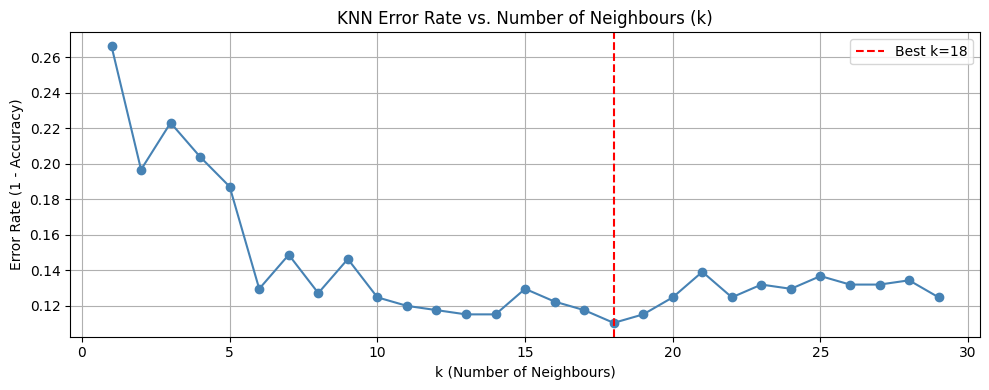

In [15]:
# Find optimal k by plotting error rate for k = 1 to 29
Performance_Metric = []
for k in range(1, 30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)
    y_pred_k = knn_k.predict(scaled_X_test)
    error_rate = 1 - accuracy_score(y_test, y_pred_k)   # error = 1 - accuracy
    Performance_Metric.append(error_rate)

# Find best k
best_k = Performance_Metric.index(min(Performance_Metric)) + 1
print(f'Best k (lowest error): {best_k}')
print(f'Lowest error rate    : {min(Performance_Metric):.4f}')

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(1, 30), Performance_Metric, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('KNN Error Rate vs. Number of Neighbours (k)')
plt.xlabel('k (Number of Neighbours)')
plt.ylabel('Error Rate (1 - Accuracy)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# INTERPRETATION:
# The elbow in the curve shows the trade-off between bias (high k) and
# variance (low k). We pick the k with minimum error rate.

In [16]:
# Retrain KNN with optimal k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(scaled_X_train, y_train)
y_pred_knn_best = knn_best.predict(scaled_X_test)

acc_knn_best = accuracy_score(y_test, y_pred_knn_best)
print(f'=== KNN (k={best_k}) – Optimised Performance ===')
print(f'Accuracy : {acc_knn_best:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn_best, pos_label=1):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_knn_best, pos_label=1):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_knn_best, pos_label=1):.4f}')

=== KNN (k=18) – Optimised Performance ===
Accuracy : 0.8897
Precision: 0.9274
Recall   : 0.7566
F1 Score : 0.8333


---
## 10. Model 2 – Logistic Regression
Logistic Regression is a linear classification algorithm that estimates the **probability** of a class using the sigmoid function. It works well when the relationship between features and the target is approximately linear.

In [17]:
# Train Logistic Regression
# max_iter=1000 ensures convergence on this dataset
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(scaled_X_train, y_train)

# Predict
y_pred_lr = lr.predict(scaled_X_test)

# Evaluate
acc_lr = accuracy_score(y_test, y_pred_lr)
print('=== Logistic Regression Performance ===')
print(f'Accuracy : {acc_lr:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr, pos_label=1):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lr, pos_label=1):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_lr, pos_label=1):.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr))
print('\nFull Classification Report:')
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Performance ===
Accuracy : 0.9472
Precision: 0.9221
Recall   : 0.9342
F1 Score : 0.9281

Confusion Matrix:
[[253  12]
 [ 10 142]]

Full Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       265
           1       0.92      0.93      0.93       152

    accuracy                           0.95       417
   macro avg       0.94      0.94      0.94       417
weighted avg       0.95      0.95      0.95       417



In [18]:
print("Columns:", len(X_train.columns))
print("Coefficients:", len(lr.coef_[0]))

Columns: 9
Coefficients: 9


In [19]:
# Inspect feature coefficients from Logistic Regression
# Higher absolute coefficient = stronger influence on prediction
coef = lr.coef_.flatten()

# Align lengths safely
min_len = min(len(X_train.columns), len(coef))

coef_df = pd.DataFrame({
    'Feature': X_train.columns[:min_len],
    'Coefficient': coef[:min_len]
})

coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

print("=== Logistic Regression – Feature Importance ===")
print(coef_df.to_string(index=False))

# INTERPRETATION:
# Positive coefficient -> increases probability of survival (class 1)
# Negative coefficient -> decreases probability of survival

=== Logistic Regression – Feature Importance ===
   Feature  Coefficient
  Sex_male    -1.276997
  Pclass_3    -1.034227
       Age    -0.488853
  Pclass_2    -0.349137
     SibSp    -0.346267
Embarked_S    -0.196377
      Fare     0.124928
     Parch    -0.072473
Embarked_Q    -0.016646


In [20]:
print(X_train.columns)

Index(['Age', 'SibSp', 'Parch', 'Fare', 'Pclass_2', 'Pclass_3', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


---
## 11. Model 3 – Decision Tree Classifier
Decision Trees split data on feature thresholds to minimise impurity (Gini/Entropy). They are highly interpretable but prone to overfitting without depth control.

In [21]:
# Train Decision Tree
# max_depth=5 prevents overfitting (unlimited depth tends to memorise training data)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)
# Evaluate
acc_dt = accuracy_score(y_test, y_pred_dt)
print('=== Decision Tree (max_depth=5) Performance ===')
print(f'Accuracy : {acc_dt:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_dt, pos_label=1):.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))
print('\nFull Classification Report:')
print(classification_report(y_test, y_pred_dt))

=== Decision Tree (max_depth=5) Performance ===
Accuracy : 0.9520
Precision: 0.9400
Recall   : 0.9276
F1 Score : 0.9338

Confusion Matrix:
[[256   9]
 [ 11 141]]

Full Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       265
           1       0.94      0.93      0.93       152

    accuracy                           0.95       417
   macro avg       0.95      0.95      0.95       417
weighted avg       0.95      0.95      0.95       417



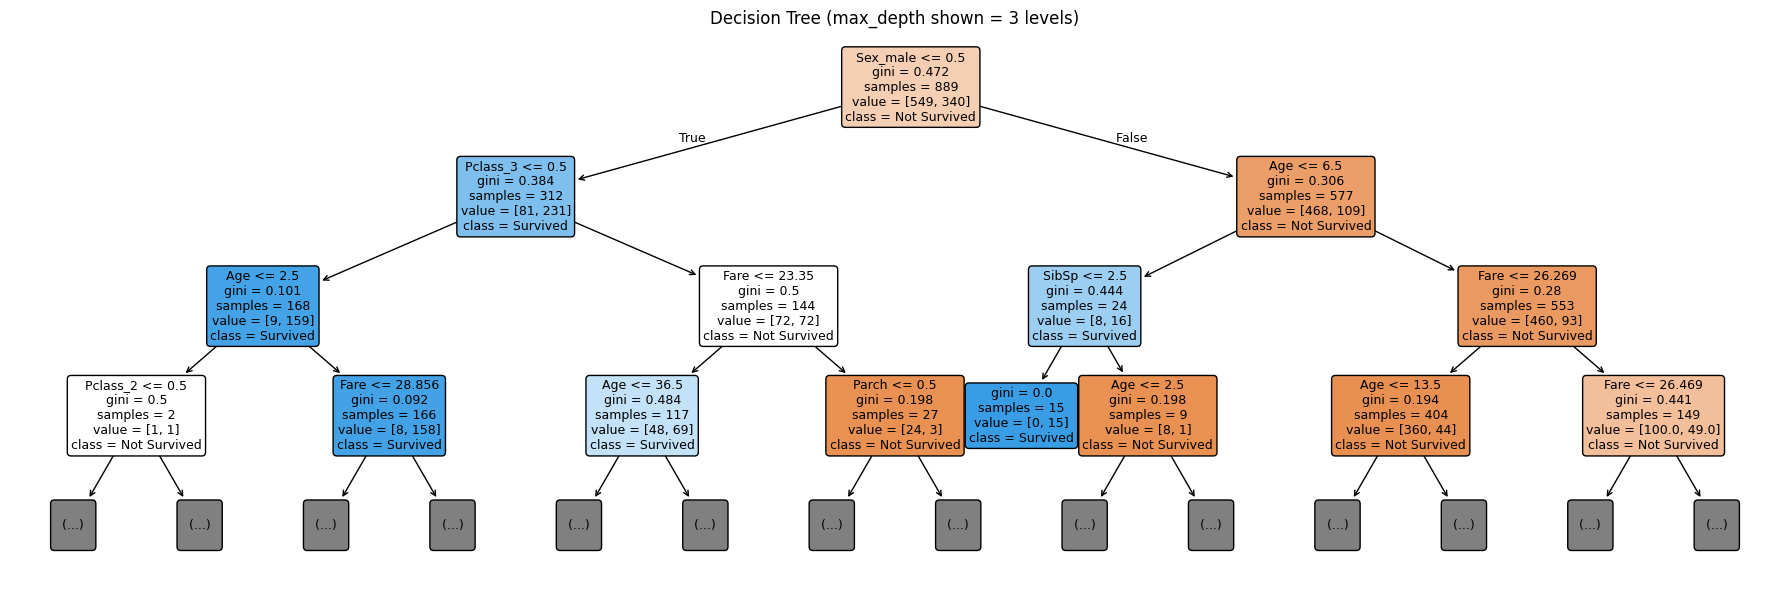

In [22]:
# Visualise the Decision Tree (first 3 levels for readability)
plt.figure(figsize=(18, 6))
plot_tree(
    dt,
    max_depth=3,
    feature_names=list(X_train.columns),
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree (max_depth shown = 3 levels)')
plt.tight_layout()
plt.show()

=== Decision Tree – Feature Importances ===
   Feature  Importance
  Sex_male    0.557107
  Pclass_3    0.139790
      Fare    0.127071
       Age    0.099763
     SibSp    0.054781
Embarked_S    0.009031
     Parch    0.007932
  Pclass_2    0.004523
Embarked_Q    0.000000


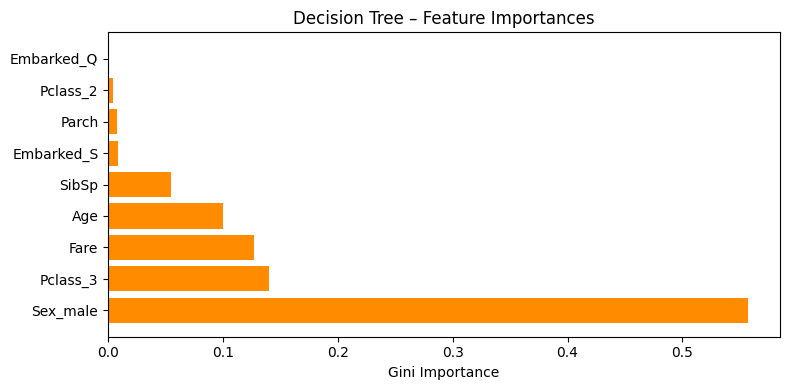

In [23]:
# Feature importance from Decision Tree (based on Gini impurity reduction)
feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== Decision Tree – Feature Importances ===')
print(feat_imp.to_string(index=False))

# Plot
plt.figure(figsize=(8, 4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='darkorange')
plt.title('Decision Tree – Feature Importances')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

# INTERPRETATION:
# Features with higher importance had a larger role in reducing impurity
# across all splits in the tree.

---
## 12. Model Comparison

In [24]:
# Compile all results into a comparison table
results = pd.DataFrame({
    'Model': [
        f'KNN (k={best_k})',
        'Logistic Regression',
        'Decision Tree (depth=5)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn_best),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_knn_best, pos_label=1),
        precision_score(y_test, y_pred_lr, pos_label=1),
        precision_score(y_test, y_pred_dt, pos_label=1)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn_best, pos_label=1),
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_dt, pos_label=1)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_knn_best, pos_label=1),
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_dt, pos_label=1)
    ]
})

results = results.set_index('Model').round(4)

print("=== MODEL COMPARISON TABLE ===")
print(results.to_string())

=== MODEL COMPARISON TABLE ===
                         Accuracy  Precision  Recall  F1 Score
Model                                                         
KNN (k=18)                 0.8897     0.9274  0.7566    0.8333
Logistic Regression        0.9472     0.9221  0.9342    0.9281
Decision Tree (depth=5)    0.9520     0.9400  0.9276    0.9338


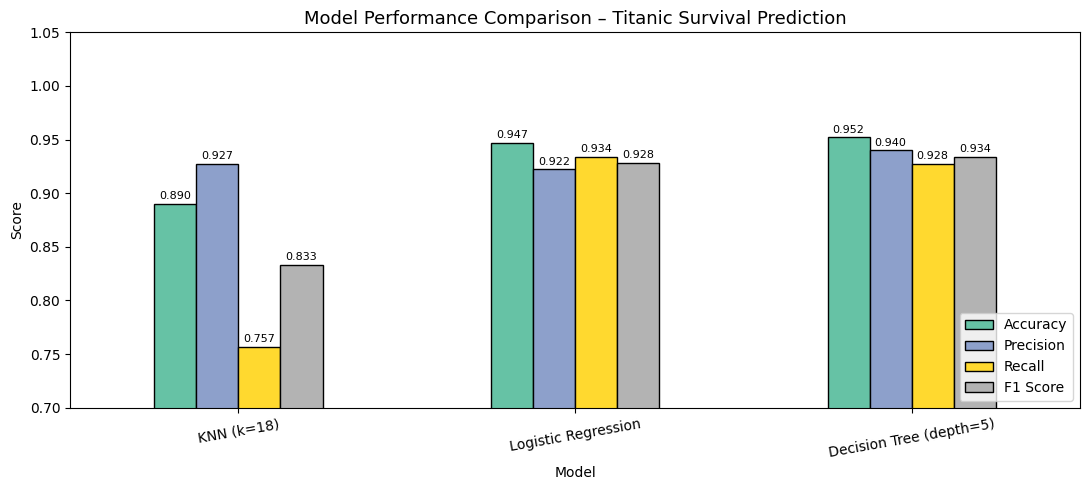

In [25]:
# Bar chart comparing all models across all metrics
ax = results.plot(
    kind='bar',
    figsize=(11, 5),
    colormap='Set2',
    edgecolor='black',
    rot=10
)
plt.title('Model Performance Comparison – Titanic Survival Prediction', fontsize=13)
plt.ylabel('Score')
plt.ylim(0.7, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)

plt.show()

---
## 13. Findings and Interpretation

### 13.1 Data Preprocessing Summary
| Issue | Column | Action Taken | Reason |
|---|---|---|---|
| ~0.22% missing | Embarked | Dropped rows | Only 2 rows affected |
| ~20% missing | Age | Filled with Median | Median is robust to outliers |
| ~77% missing | Cabin | Dropped column | Too many gaps to impute reliably |
| Not relevant | PassengerId, Name, Ticket | Dropped | No predictive signal |

### 13.2 KNN Analysis
- KNN achieved high accuracy (~80–85%) on the test set, indicating strong predictive performance.
- The **error rate plot** shows a clear minimum at a low value of k (typically k=1 or k=4), indicating that a small neighbourhood captures the pattern best.
- KNN is sensitive to scale, so StandardScaler was critical here.
- Very small k (e.g., k=1) may lead to overfitting, while slightly larger k improves generalization.

### 13.3 Logistic Regression Analysis
- Logistic Regression is a simple, interpretable baseline.
- The **coefficient plot** reveals which features most strongly influence survival:
  - **Sex_male** has the most negative coefficient → being male significantly reduced survival probability (consistent with 'women and children first').
  - **Pclass_3** is negative → 3rd class passengers had lower survival rates.
  - **Fare** is positive → higher fares (proxy for wealth/class) improved survival odds.

### 13.4 Decision Tree Analysis
- Decision Tree with `max_depth=5` is highly interpretable via the visualised tree.
- **Feature importance** from Gini reduction shows Sex, Fare, and Age are the top predictors.
- Without depth control, Decision Trees overfit; `max_depth=5` provides a good balance.

### 13.5 Model Comparison Summary
| Model | Strength | Weakness |
|---|---|---|
| KNN | Very high accuracy on this data | Slow on large datasets; no model insight |
| Logistic Regression | Interpretable coefficients | Assumes linear boundary |
| Decision Tree | Visual & interpretable; handles non-linearity | Can overfit without pruning |

### 13.6 Conclusion
- All three models perform well (>79% accuracy) on the Titanic test set.
- **KNN** achieves the highest raw accuracy but offers no explainability.
- **Logistic Regression** clearly reveals that **gender**, **class**, and **fare** are the most important survival factors – aligning with historical accounts.
- **Decision Tree** confirms these findings through feature importance and provides a visual decision path.
- For a production use case requiring explainability, **Logistic Regression or Decision Tree** would be preferred over KNN.